# ⚡ CircuitVQA — Génération du Dataset

> **Objectif :** Générer un dataset **CircuitVQA** de haute qualité pour l'entraînement et l'évaluation de modèles de compréhension de circuits.

### 📦 Configuration du dataset

- **📝 48 templates** de questions
- **🔧 22 classes** de composants
- **🌐 2 domaines**
  - ⚡ Circuits électriques
  - 💻 Circuits logiques

---

## 🚀 Pipeline de génération

| Étape | Description | Statut |
|:---:|---|:---:|
| **1** | Vérification de l'installation et des dépendances | ⬜ |
| **2** | Test visuel : génération d'un circuit par template | ⬜ |
| **3** | Vérification des annotations (overlay) | ⬜ |
| **4** | Mini-génération (**60 train + 15 val**) et validation | ⬜ |
| **5** | **Génération complète (4500 train + 500 val)** | ⬜ |
| **6** | Validation du dataset complet | ⬜ |
| **7** | Analyse statistique (classes, domaines, unicité) | ⬜ |

---

## 🎯 Résultat attendu

- ✅ Dataset cohérent
- ✅ Annotations correctes
- ✅ Répartition équilibrée des classes
- ✅ Aucune duplication d'images
- ✅ Prêt pour l'entraînement des modèles VQA

## Étape 1 — Vérification de l'installation

In [4]:
import sys
import json
import random
import shutil
from pathlib import Path
from collections import Counter
import schemdraw
import cv2

PROJECT_ROOT = Path("..").resolve()
DG = PROJECT_ROOT / "Src" / "Data_Generation"
assert DG.exists(), f"Dossier introuvable : {DG}"

# Add source directory to Python path
if str(DG) not in sys.path:
    sys.path.insert(0, str(DG))

from Circuit_Catalog import (
    CATALOG,
    instantiate,
    list_templates_by_level,
    list_templates_by_domain
)

from Renderer import sample_style

from Renderer_Annotated import (
    CircuitRendererAnnotated,
    CLASS_NAMES
)

from Validate_Dataset import validate_record
import Generate_Dataset as gd

print("📁 Data Generation path:")
print(DG)
print("\nschemdraw version:", schemdraw.__version__)

# Templates statistics
dom = list_templates_by_domain()

print(
    f"\nTemplates : {len(CATALOG)} "
    f"(Electrical: {len(dom['electrical'])}, "
    f"Logic: {len(dom['logic'])})"
)

print("\nTemplates by level:")
for lvl, names in list_templates_by_level().items():
    print(f"  - {lvl}: {len(names)}")


print(f"\nNombre de classes: {len(CLASS_NAMES)}")

print("\n✅ Environment ready!")

📁 Data Generation path:
/home/2024004/mklila01/INOVISUP_Circuit_QA/Src/Data_Generation

schemdraw version: 0.23

Templates : 48 (Electrical: 32, Logic: 16)

Templates by level:
  - lycee: 18
  - prepa: 19
  - ingenieur: 11

Nombre de classes: 22

✅ Environment ready!


## Étape 2 — Test visuel : 1 circuit par template
Chaque image utilise un style tiré au hasard (IEEE/IEC, épaisseur, police, espacement).
Vérifiez : boucle fermée pour les circuits électriques, labels lisibles, pas de chevauchement.

R_seul [electrical] : 2 comp, 2 textes, 0 jonctions, 2 nets


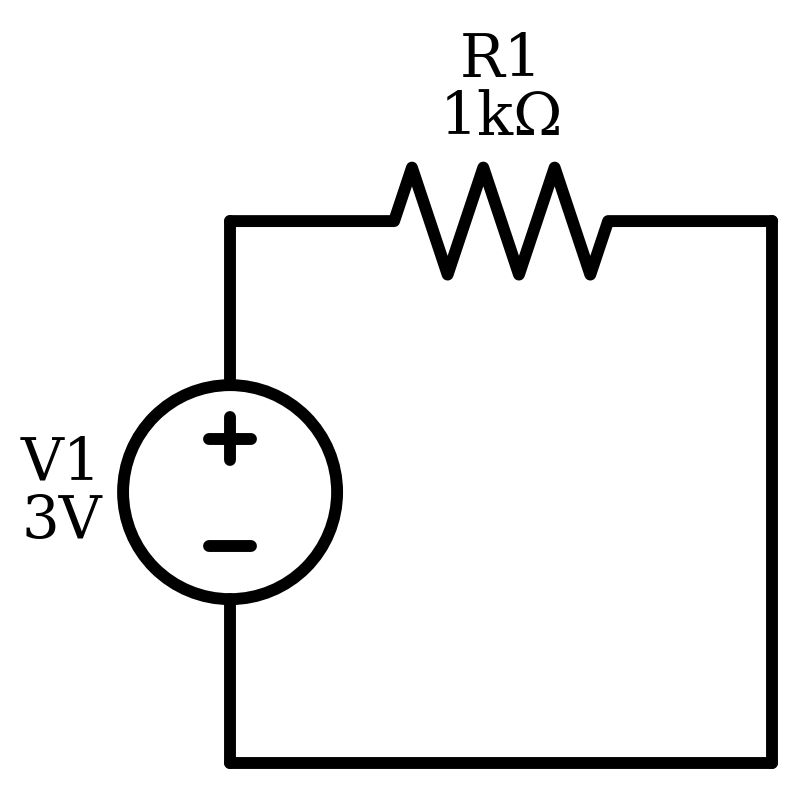

RC_series_charge [electrical] : 3 comp, 3 textes, 0 jonctions, 3 nets


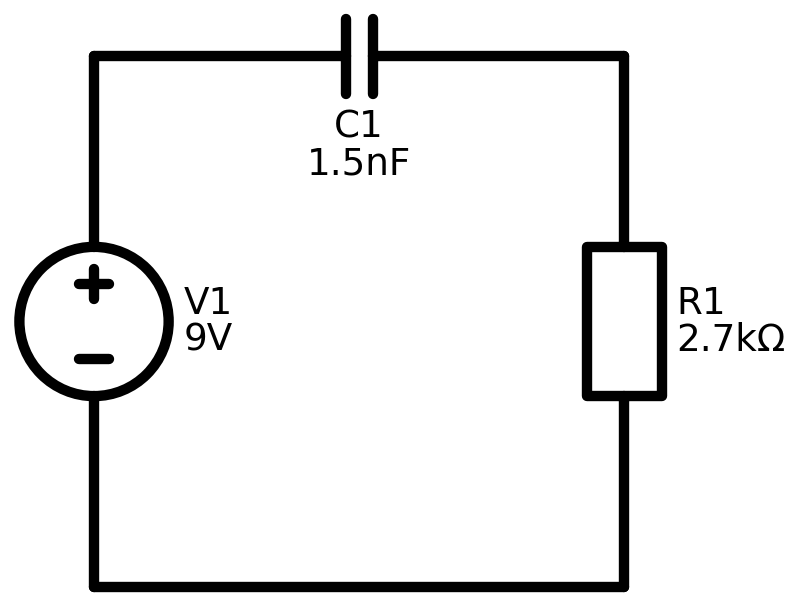

RL_series [electrical] : 3 comp, 3 textes, 0 jonctions, 3 nets


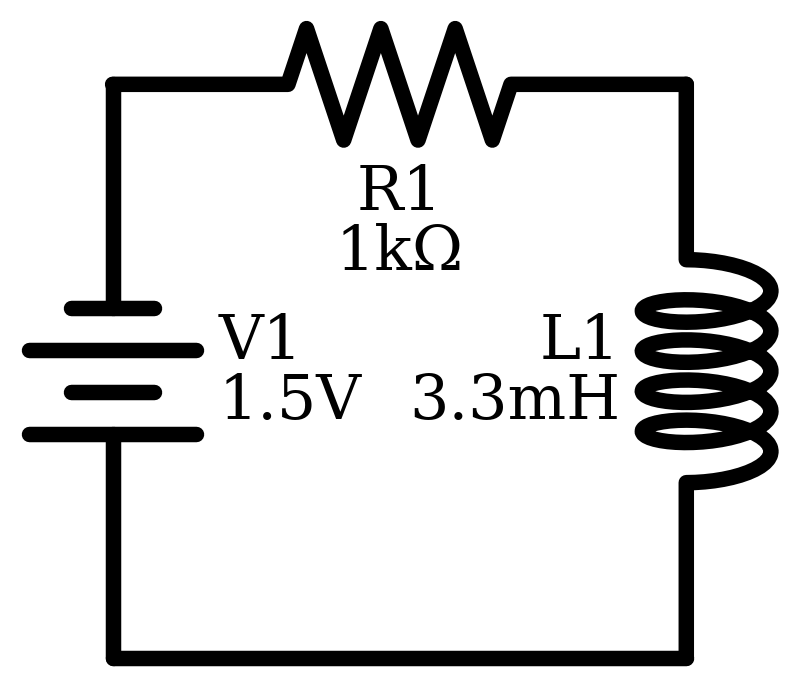

RLC_series_transient [electrical] : 4 comp, 4 textes, 0 jonctions, 4 nets


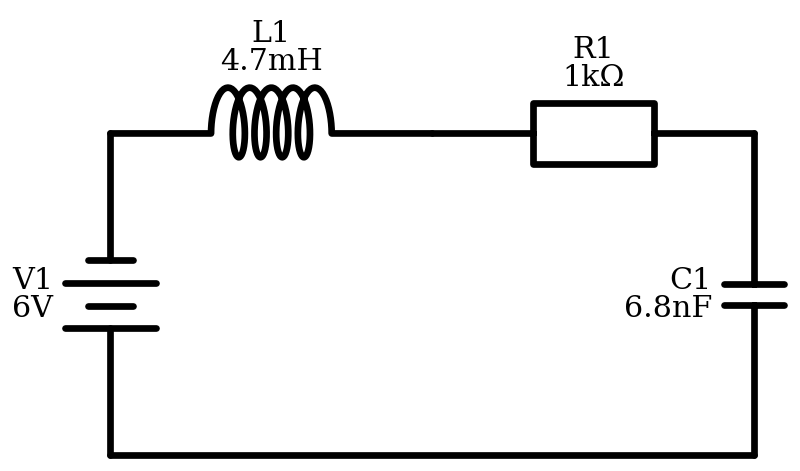

R_parallel_divider [electrical] : 3 comp, 3 textes, 4 jonctions, 2 nets


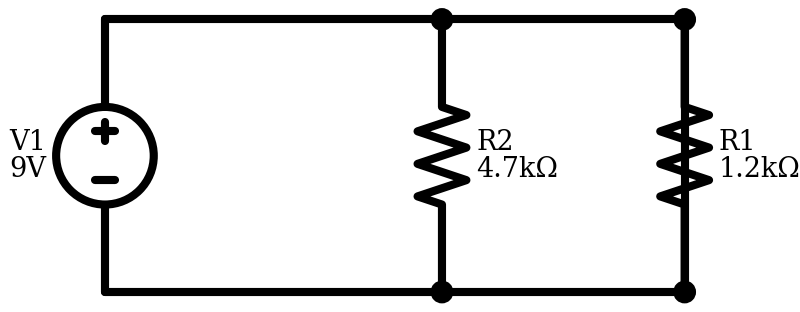

RC_parallel [electrical] : 3 comp, 3 textes, 4 jonctions, 2 nets


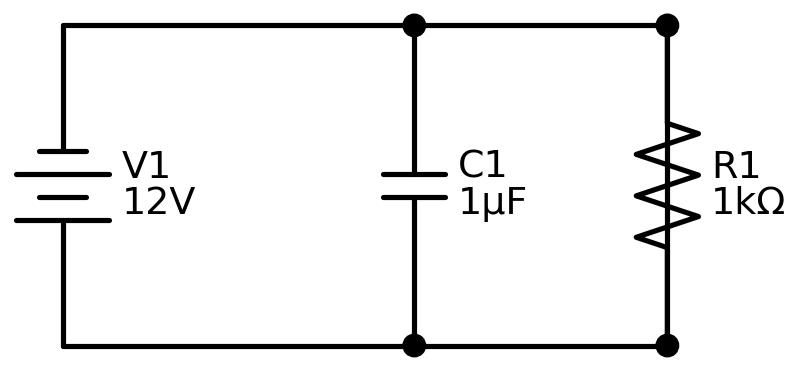

RL_parallel [electrical] : 3 comp, 3 textes, 2 jonctions, 2 nets


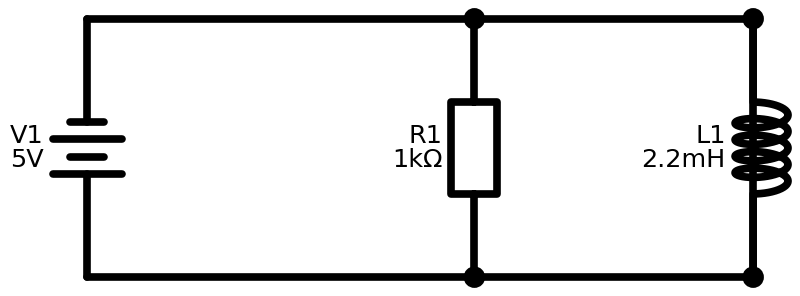

voltage_divider [electrical] : 3 comp, 3 textes, 0 jonctions, 3 nets


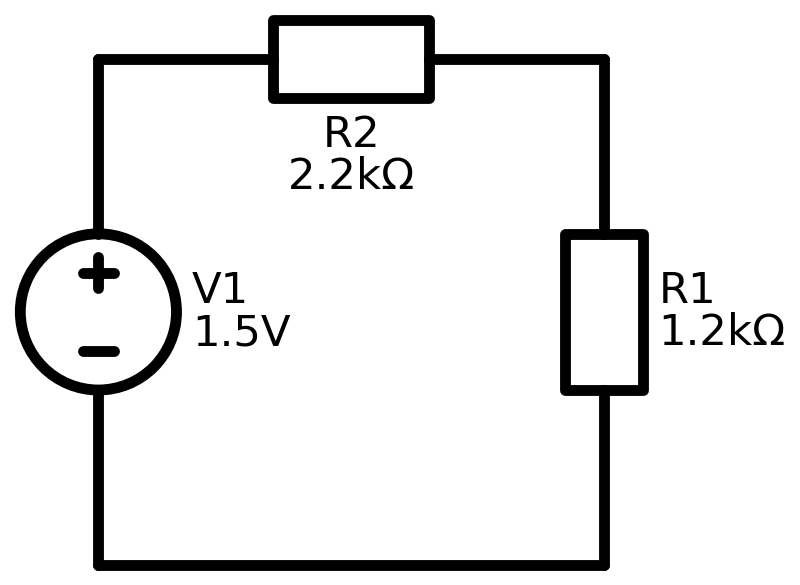

voltage_divider_loaded [electrical] : 5 comp, 4 textes, 2 jonctions, 3 nets


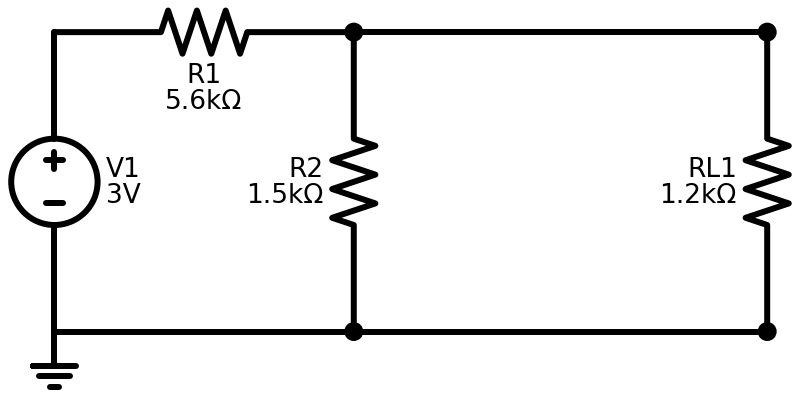

RC_lowpass [electrical] : 3 comp, 3 textes, 0 jonctions, 3 nets


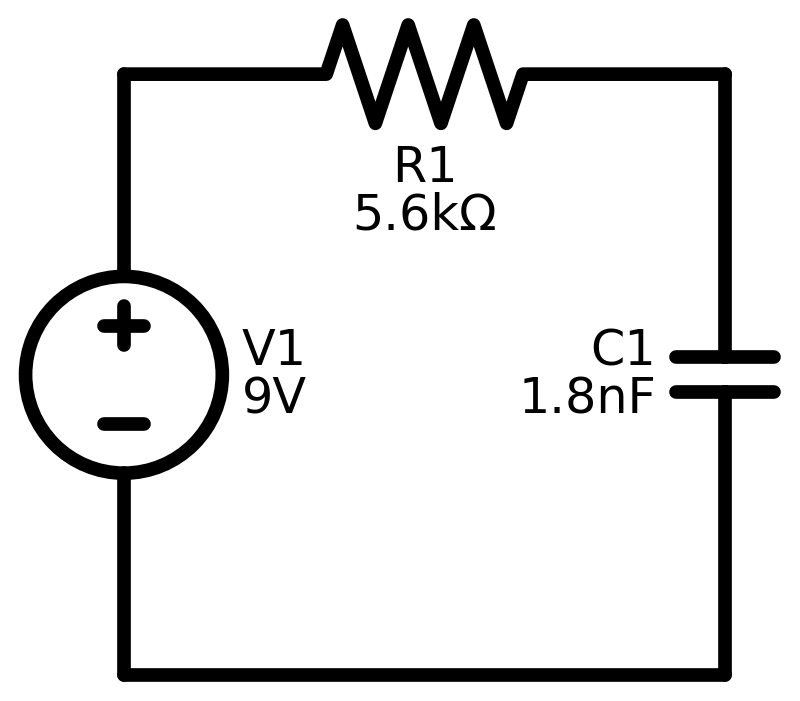

RC_highpass [electrical] : 3 comp, 3 textes, 0 jonctions, 3 nets


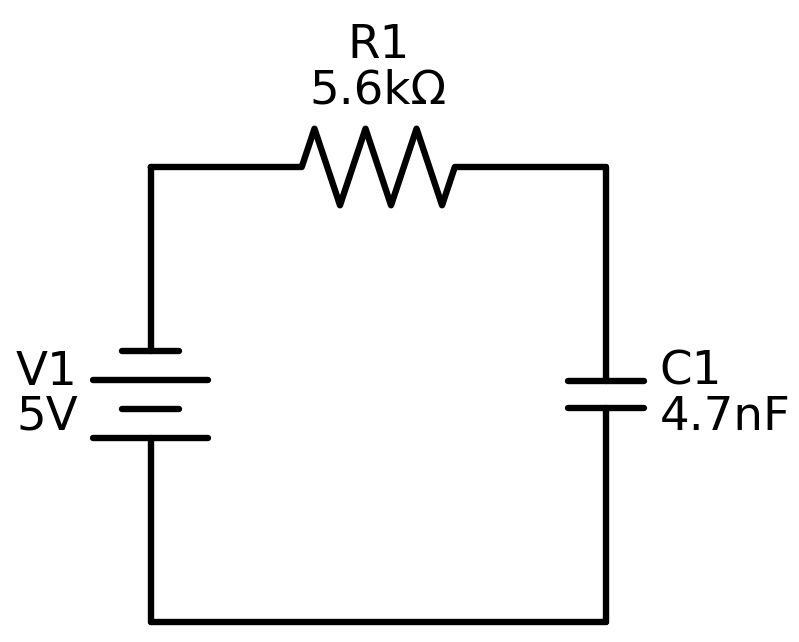

RL_lowpass [electrical] : 3 comp, 3 textes, 0 jonctions, 3 nets


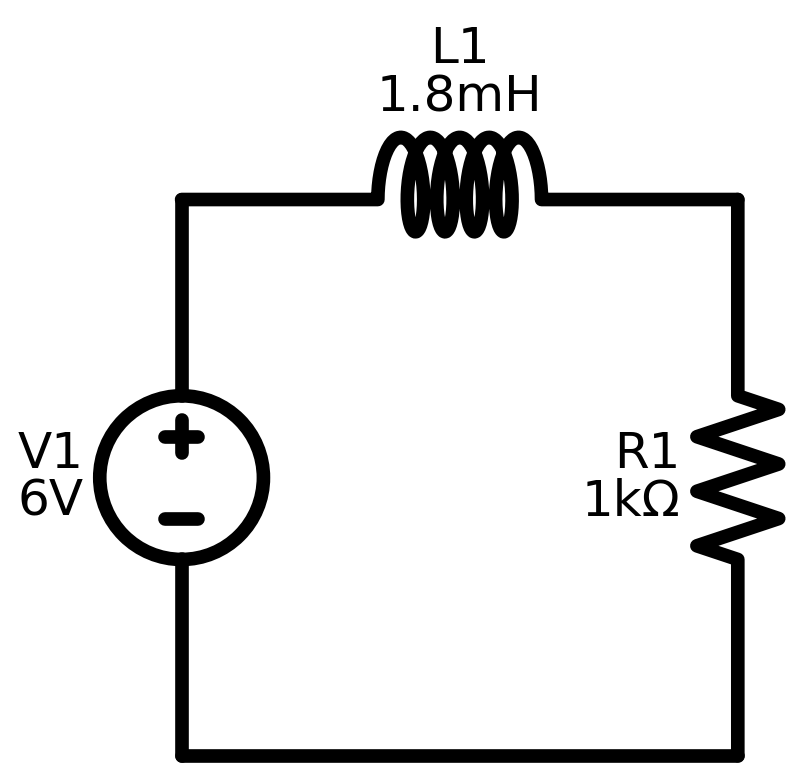

RL_highpass [electrical] : 3 comp, 3 textes, 0 jonctions, 3 nets


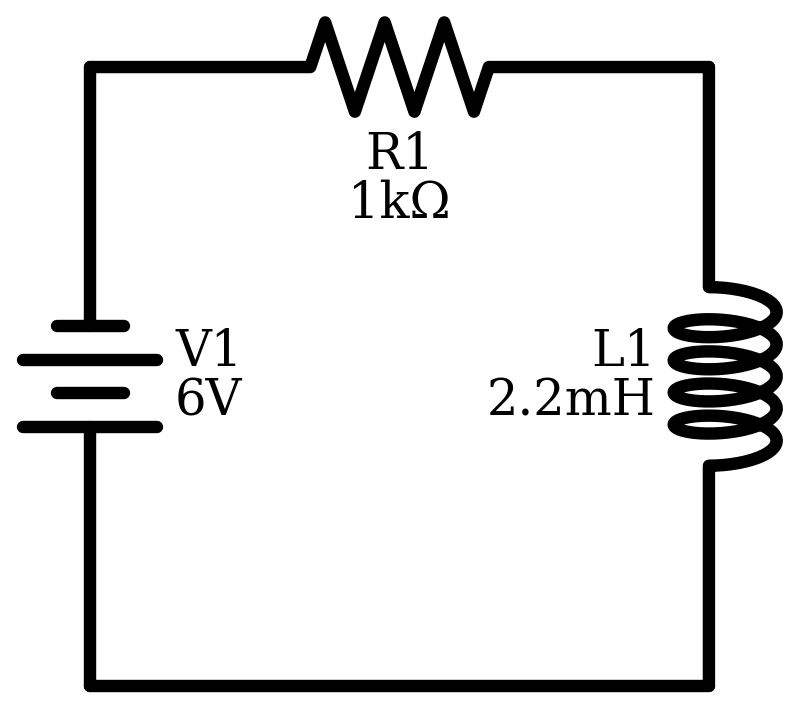

RLC_bandpass [electrical] : 4 comp, 4 textes, 0 jonctions, 4 nets


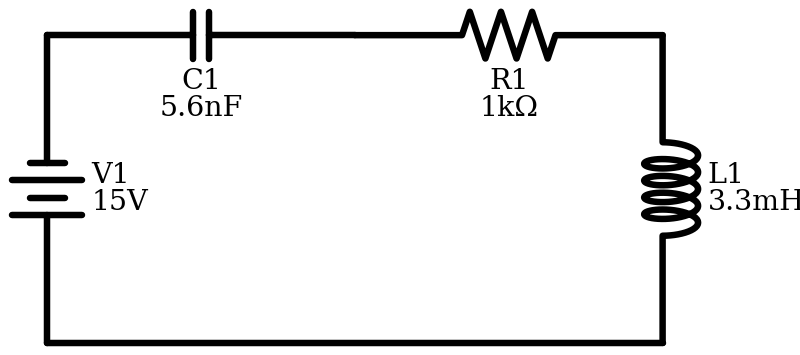

RLC_notch [electrical] : 5 comp, 4 textes, 2 jonctions, 3 nets


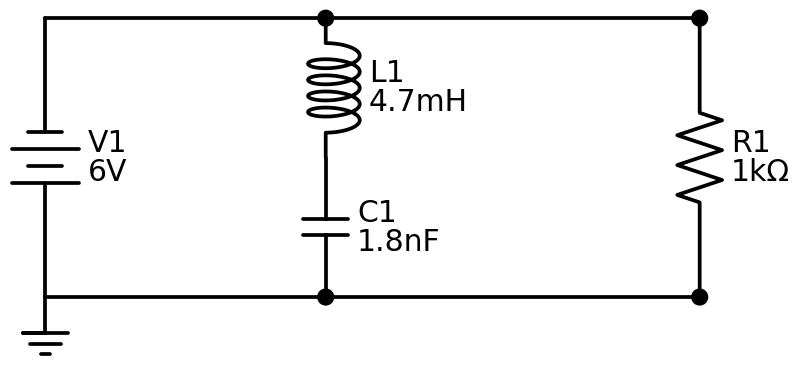

wheatstone_bridge [electrical] : 6 comp, 5 textes, 3 jonctions, 4 nets


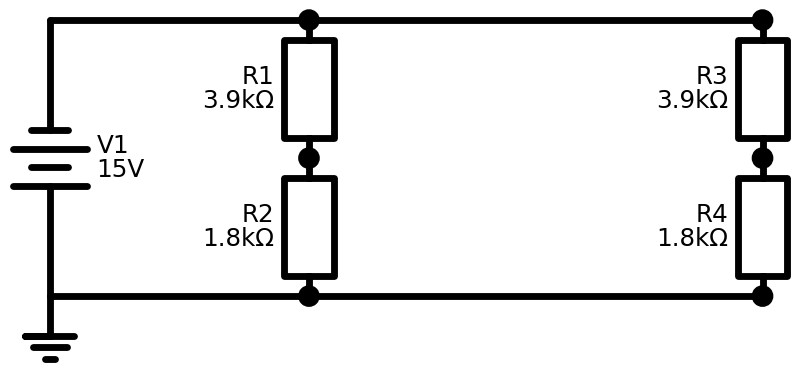

RLC_resonant_series [electrical] : 4 comp, 4 textes, 0 jonctions, 4 nets


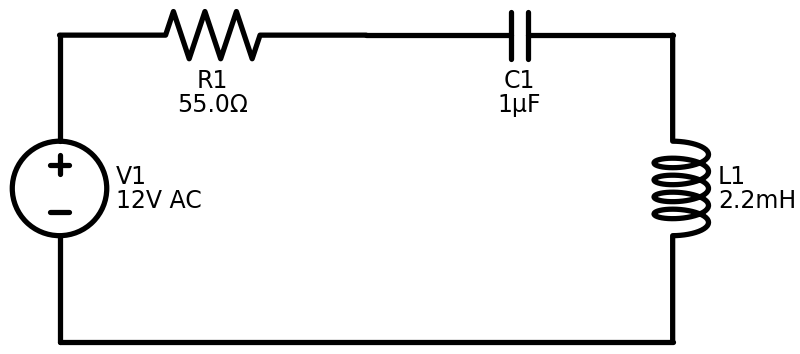

led_with_resistor [electrical] : 3 comp, 2 textes, 0 jonctions, 3 nets


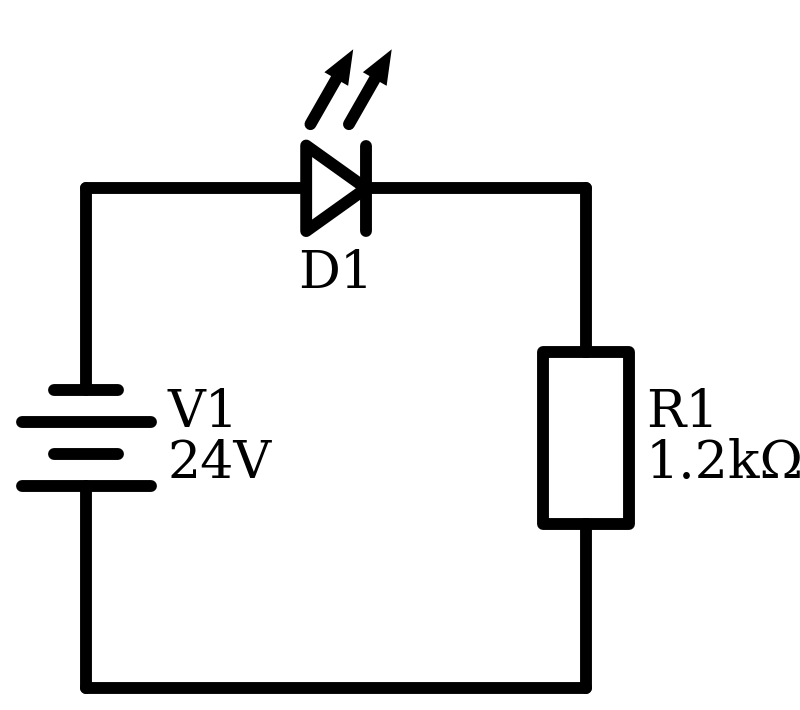

switch_led_circuit [electrical] : 4 comp, 2 textes, 0 jonctions, 4 nets


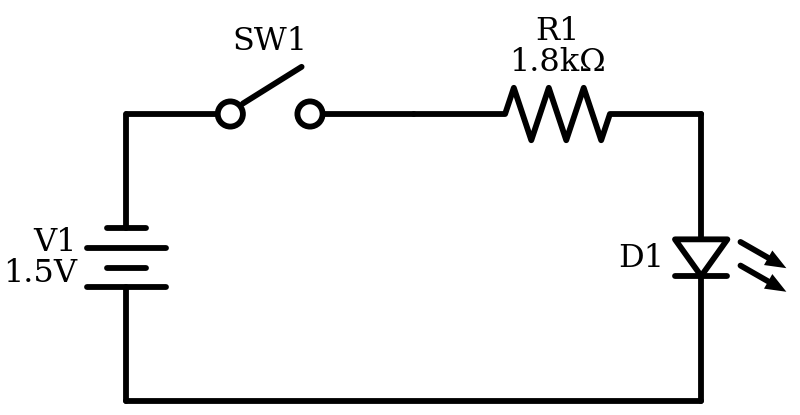

fuse_protected_load [electrical] : 3 comp, 2 textes, 0 jonctions, 3 nets


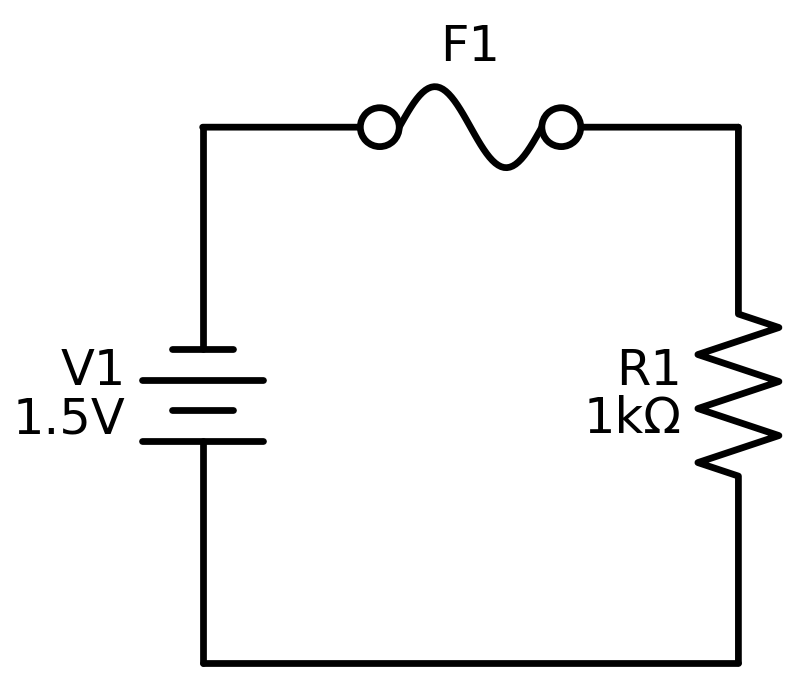

switch_two_loads [electrical] : 3 comp, 3 textes, 4 jonctions, 2 nets


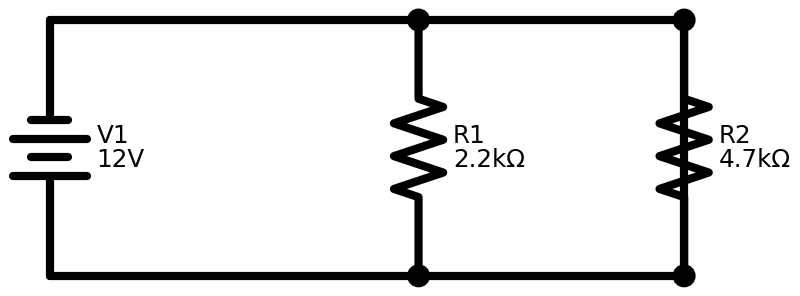

smoothing_filter [electrical] : 5 comp, 4 textes, 2 jonctions, 3 nets


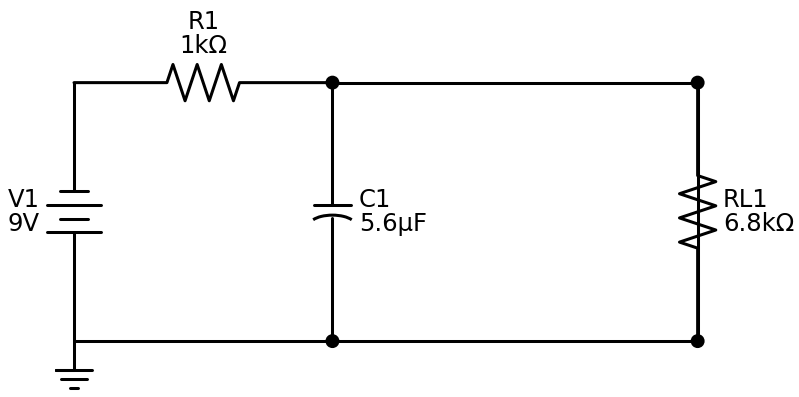

zener_regulator [electrical] : 5 comp, 4 textes, 2 jonctions, 3 nets


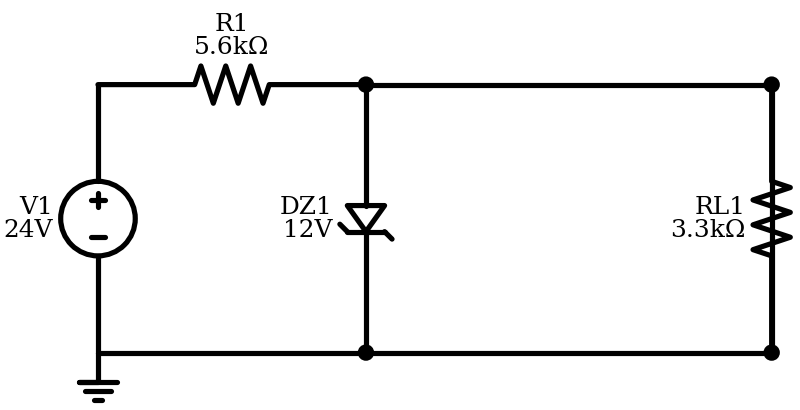

led_current_limiter [electrical] : 5 comp, 3 textes, 2 jonctions, 3 nets


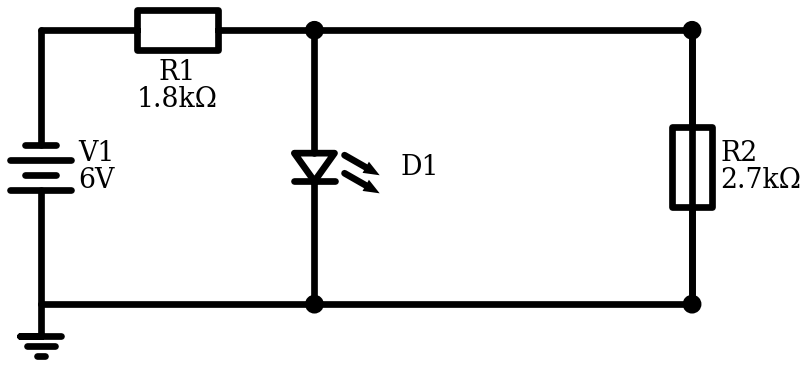

npn_common_emitter [electrical] : 5 comp, 3 textes, 1 jonctions, 4 nets


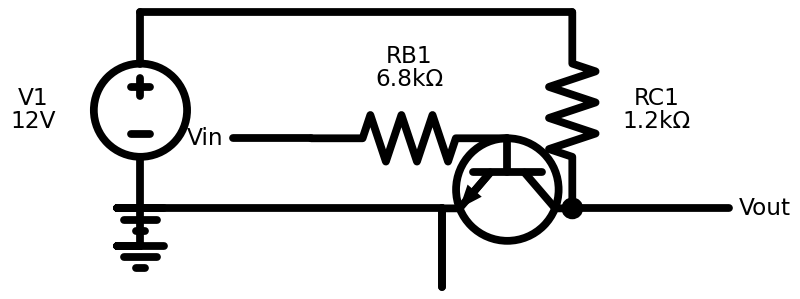

pnp_switch [electrical] : 5 comp, 3 textes, 0 jonctions, 4 nets


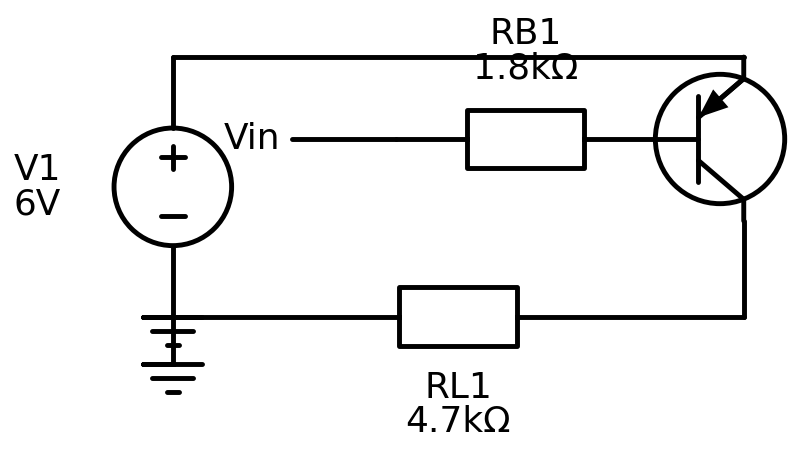

full_wave_bridge [electrical] : 6 comp, 6 textes, 3 jonctions, 4 nets


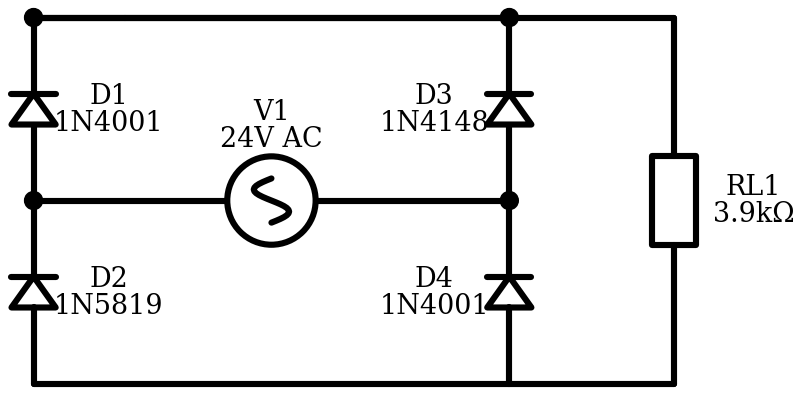

voltage_follower [electrical] : 4 comp, 3 textes, 1 jonctions, 3 nets


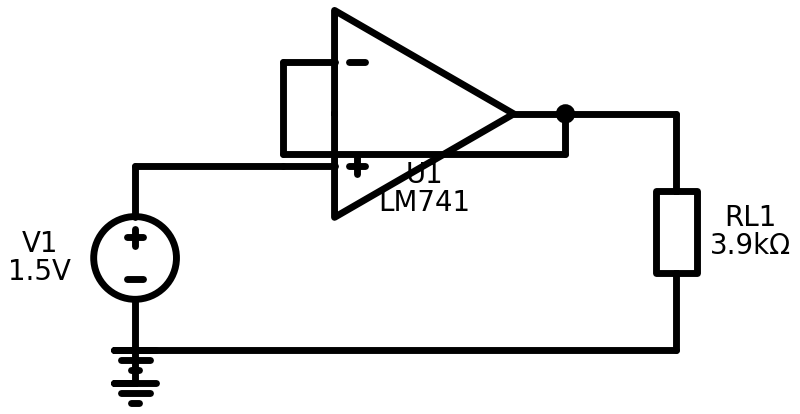

summing_amplifier [electrical] : 7 comp, 6 textes, 2 jonctions, 5 nets


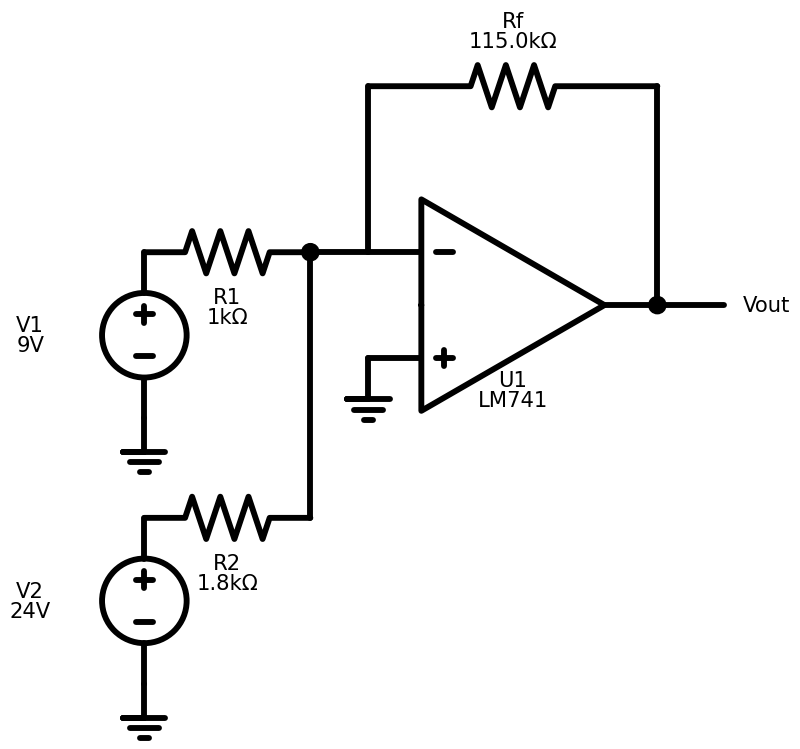

half_wave_rectifier [electrical] : 3 comp, 3 textes, 0 jonctions, 3 nets


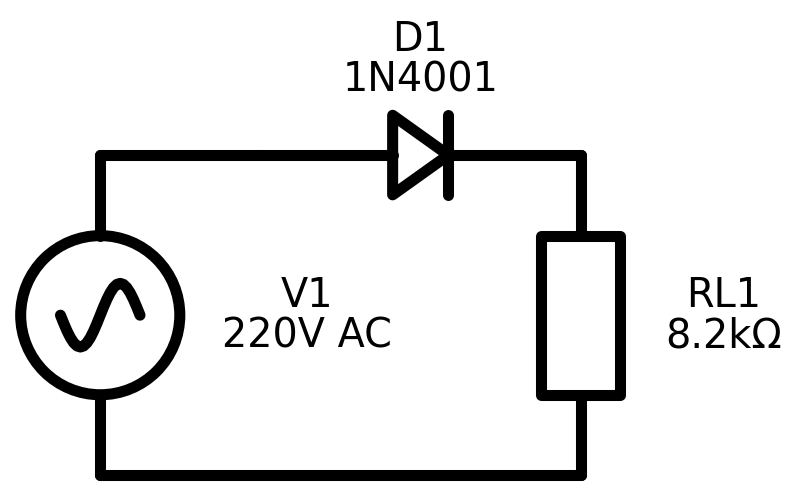

inverting_amplifier [electrical] : 5 comp, 4 textes, 2 jonctions, 4 nets


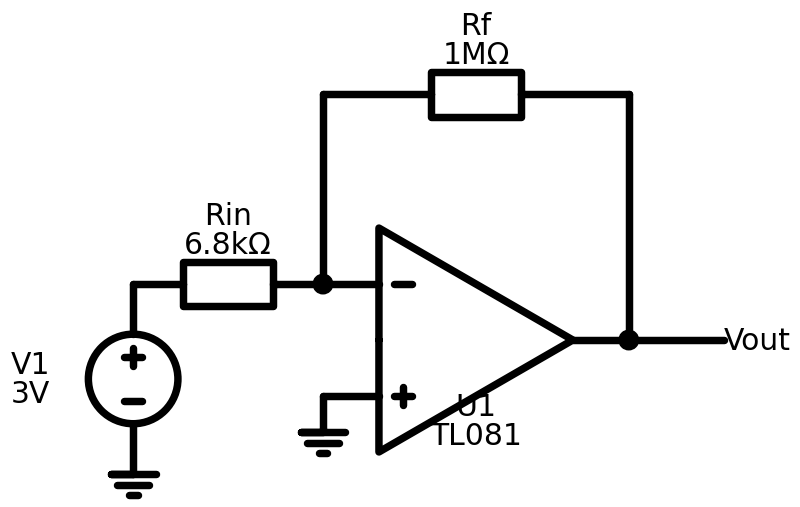

multistage_amplifier [electrical] : 8 comp, 7 textes, 4 jonctions, 4 nets


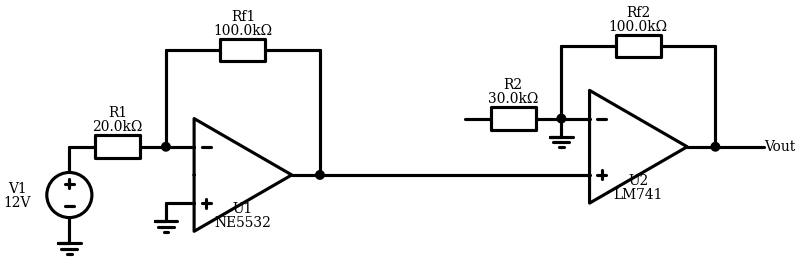

logic_and2 [logic] : 1 comp, 1 textes, 0 jonctions, 0 nets


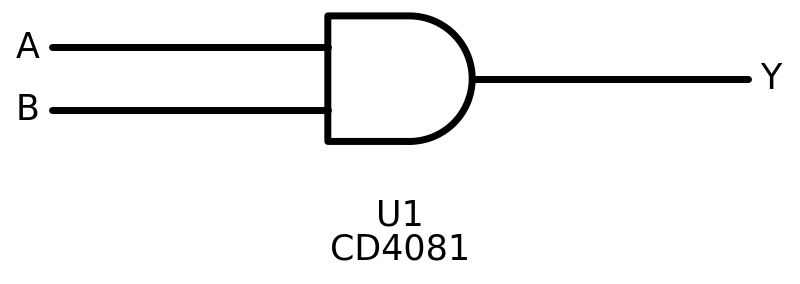

logic_or2 [logic] : 1 comp, 1 textes, 0 jonctions, 0 nets


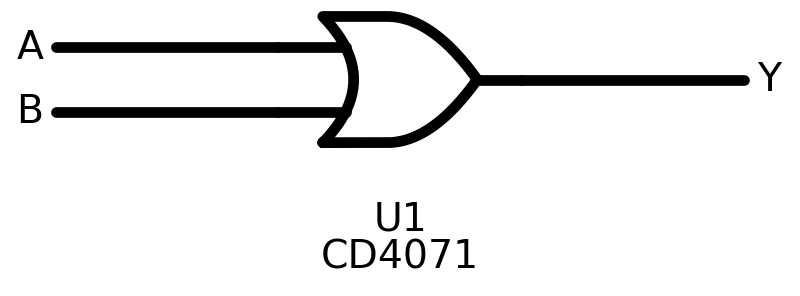

logic_not1 [logic] : 1 comp, 1 textes, 0 jonctions, 0 nets


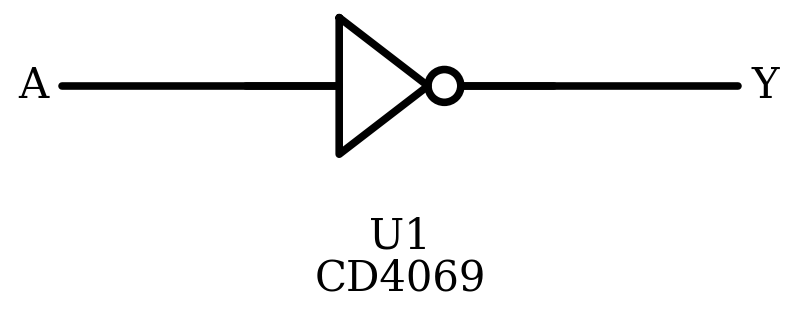

logic_nand2 [logic] : 1 comp, 1 textes, 0 jonctions, 0 nets


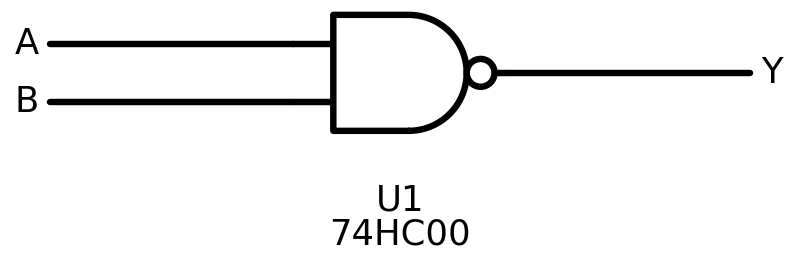

logic_nor2 [logic] : 1 comp, 1 textes, 0 jonctions, 0 nets


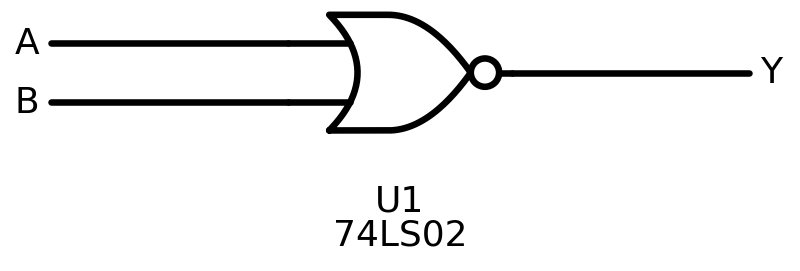

logic_xor2 [logic] : 1 comp, 1 textes, 0 jonctions, 0 nets


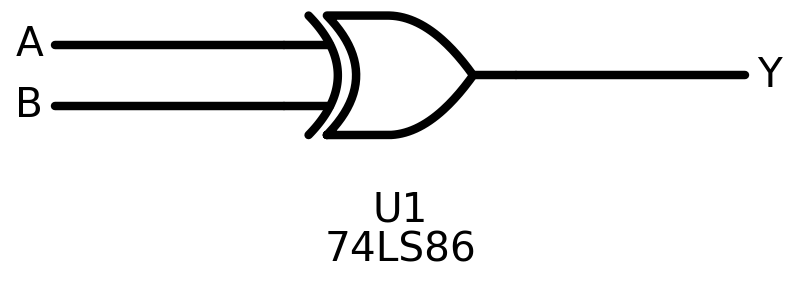

logic_xnor2 [logic] : 1 comp, 1 textes, 0 jonctions, 0 nets


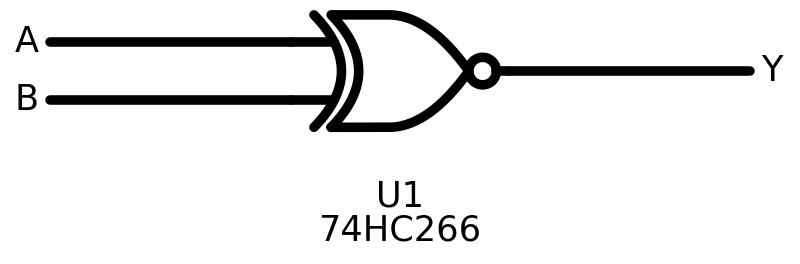

logic_and3 [logic] : 1 comp, 1 textes, 0 jonctions, 1 nets


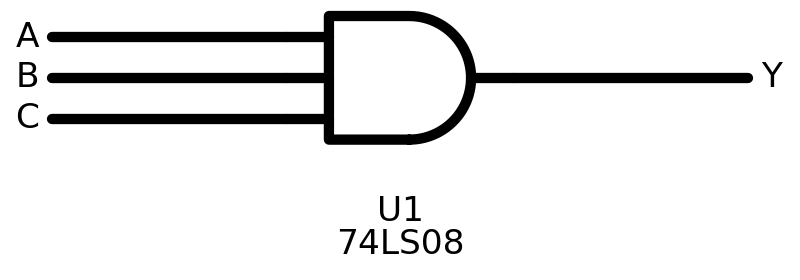

logic_nand3 [logic] : 1 comp, 1 textes, 0 jonctions, 1 nets


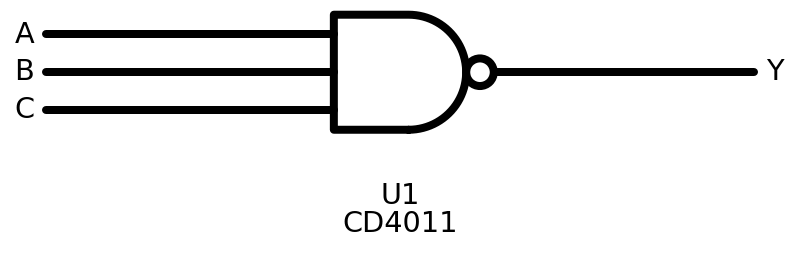

logic_or3 [logic] : 1 comp, 1 textes, 0 jonctions, 1 nets


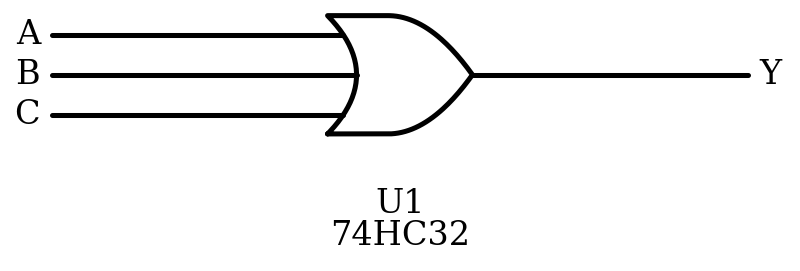

logic_and_then_or [logic] : 2 comp, 2 textes, 0 jonctions, 1 nets


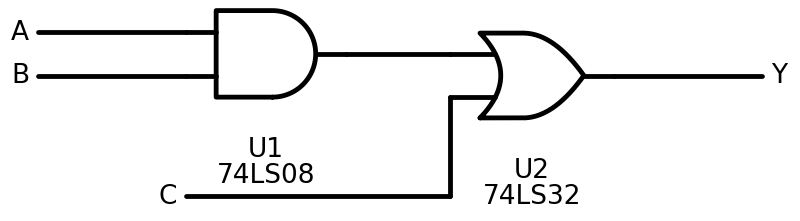

logic_or_then_and [logic] : 2 comp, 2 textes, 0 jonctions, 2 nets


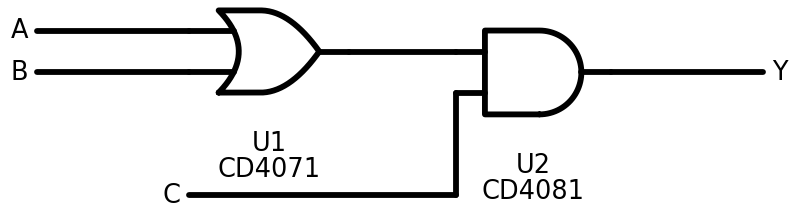

logic_xor_then_and [logic] : 2 comp, 2 textes, 0 jonctions, 2 nets


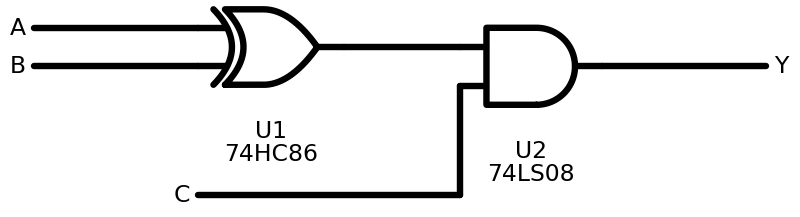

logic_nand_then_nor [logic] : 2 comp, 2 textes, 0 jonctions, 2 nets


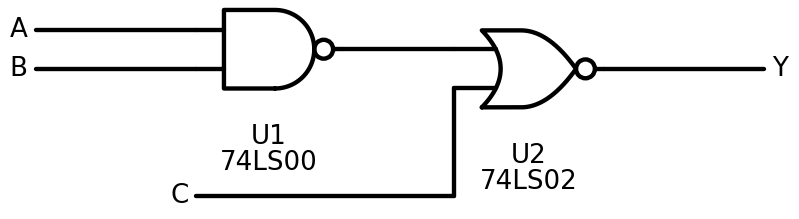

logic_half_adder [logic] : 2 comp, 2 textes, 2 jonctions, 1 nets


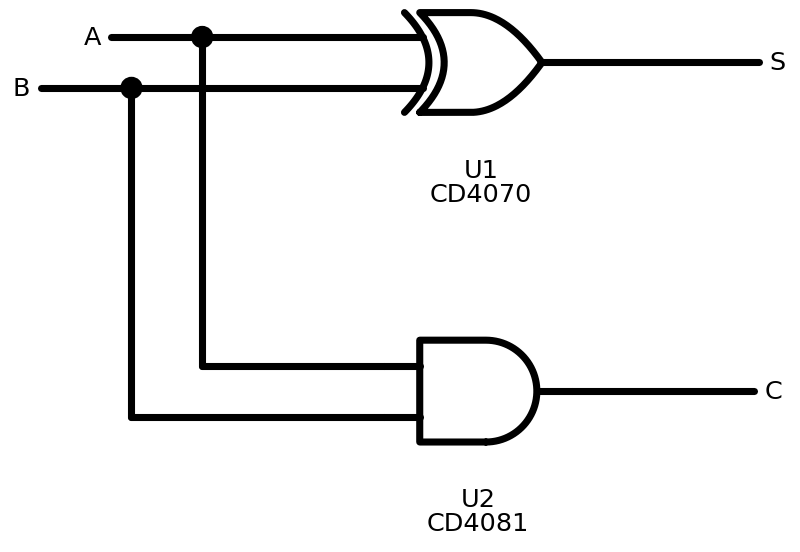

logic_demorgan [logic] : 3 comp, 3 textes, 0 jonctions, 2 nets


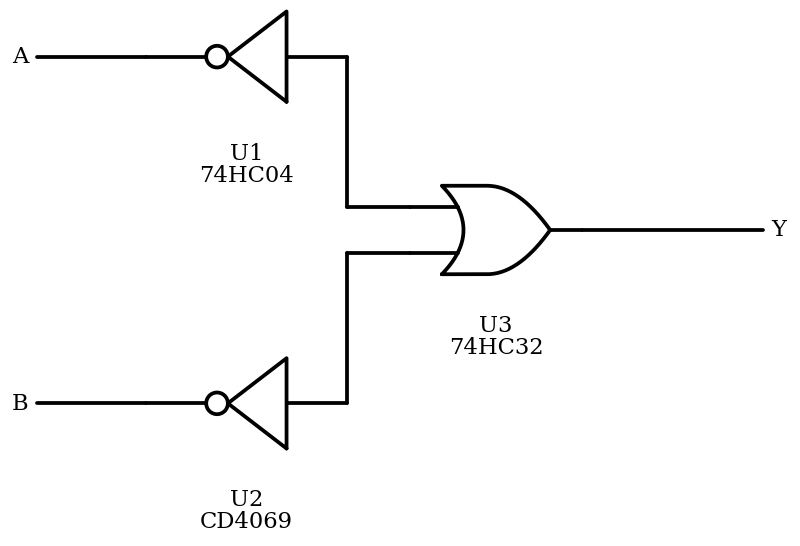

In [5]:
from IPython.display import Image as IPImage, display

random.seed(42)
TMP = Path('_tmp_visual'); TMP.mkdir(exist_ok=True)
renderer = CircuitRendererAnnotated(dpi=150, unit=3.0, png_size=800)

for tname in CATALOG.keys():
    c = instantiate(tname)
    style = sample_style(random,
                         custom=('custom_render' in c or c.get('domain') == 'logic'))
    ann = renderer.render_full(c, str(TMP/f'{tname}.svg'),
                               str(TMP/f'{tname}.png'), style=style)
    if ann is None:
        print(f'{tname}: ÉCHEC'); continue
    print(f"{tname} [{c.get('domain')}] : {len(ann['components'])} comp, "
          f"{len(ann['texts'])} textes, {len(ann['junctions'])} jonctions, "
          f"{len(ann['nets'])} nets")
    display(IPImage(filename=str(TMP/f'{tname}.png'), width=420))

## Étape 3 — Vérification des annotations (overlay)
Vert = bbox composant · Violet = bbox texte · Orange = terminaux · Rouge = jonctions

RLC_series_transient


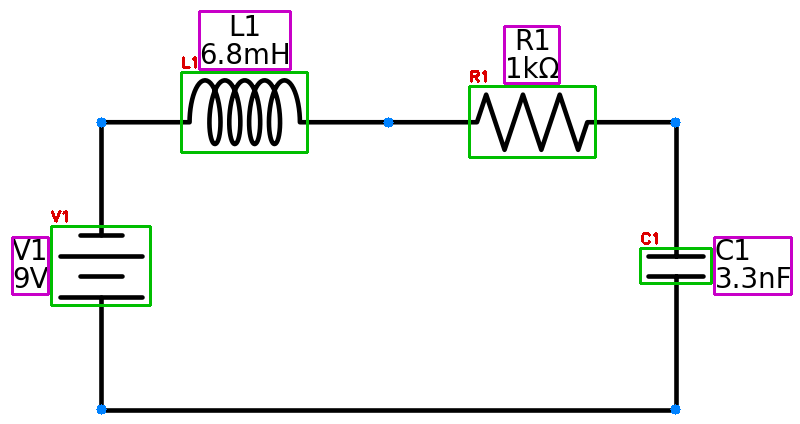

wheatstone_bridge


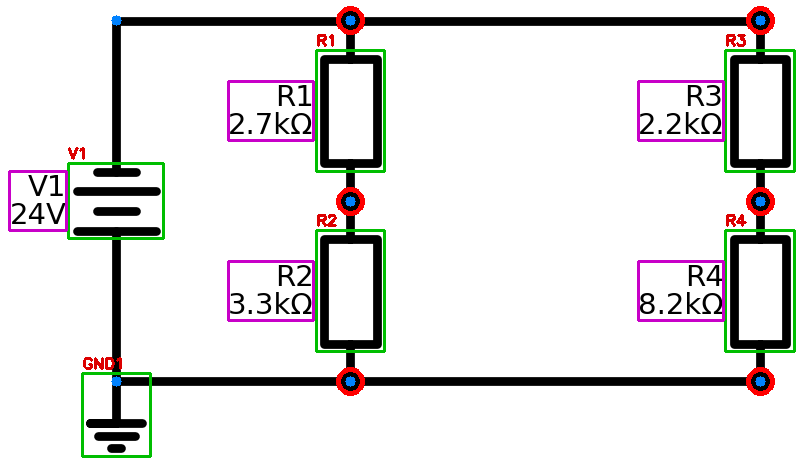

zener_regulator


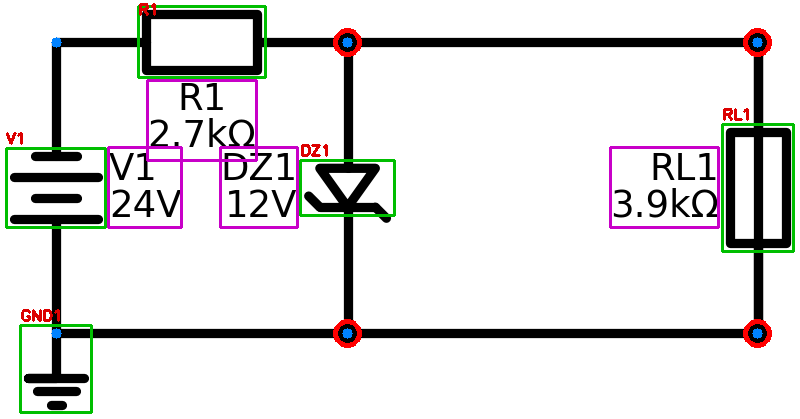

npn_common_emitter


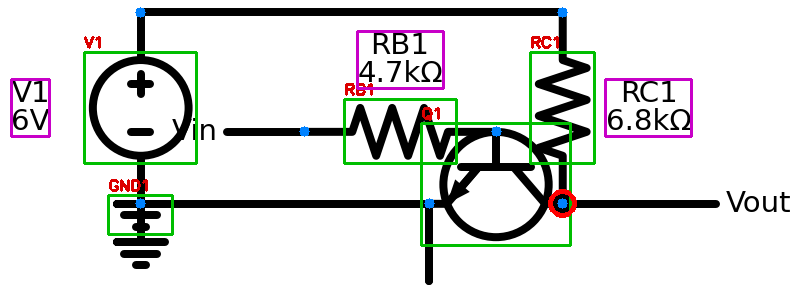

full_wave_bridge


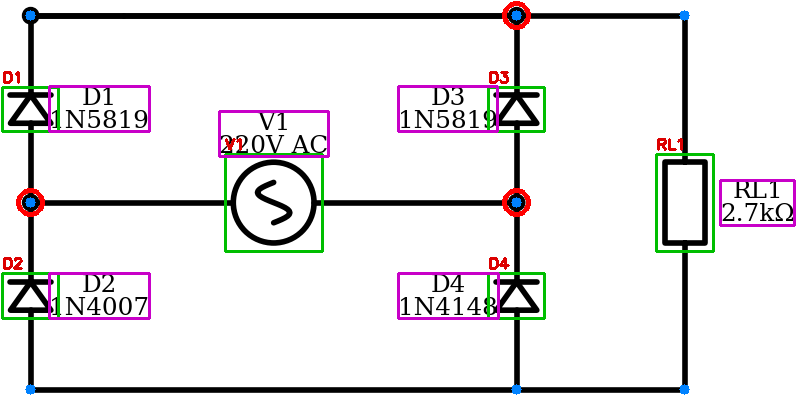

summing_amplifier


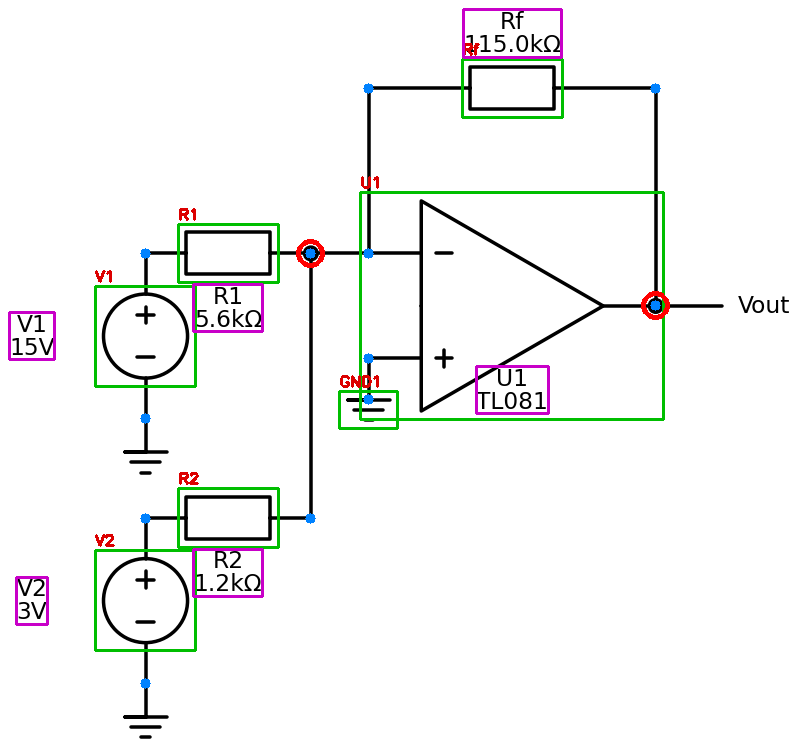

logic_half_adder


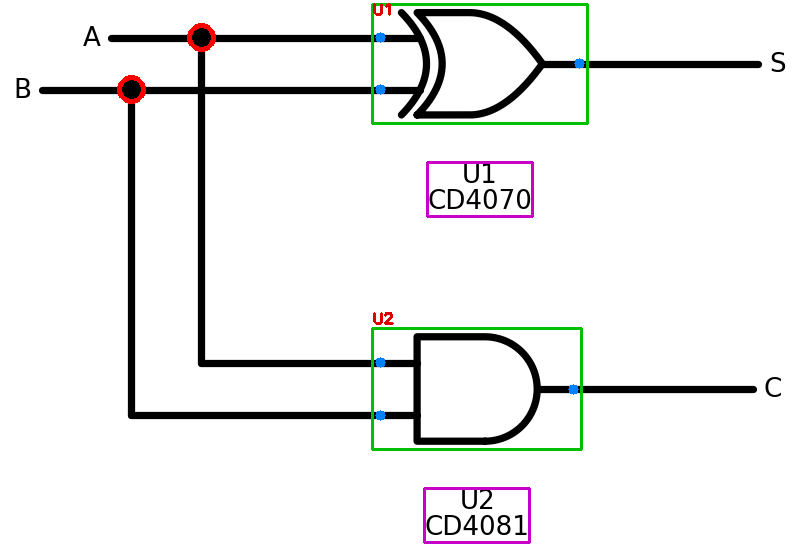

logic_demorgan


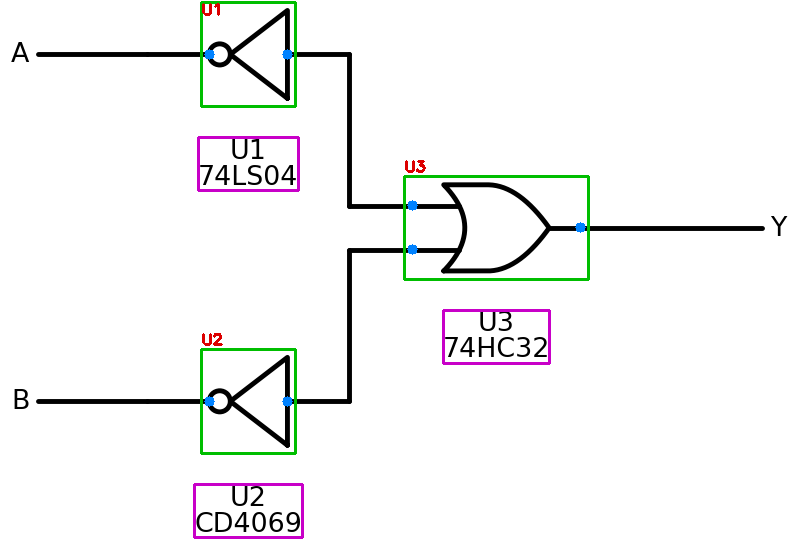

In [6]:
def draw_overlay(png_path, ann, out_path):
    img = cv2.imread(str(png_path))
    for comp in ann['components']:
        x0, y0, x1, y1 = map(int, comp['bbox'])
        cv2.rectangle(img, (x0, y0), (x1, y1), (0, 190, 0), 2)
        cv2.putText(img, comp['id'], (x0, max(14, y0-5)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 220), 2)
        for t in comp['terminals']:
            cv2.circle(img, (int(t['x']), int(t['y'])), 5, (255, 130, 0), -1)
    for t in ann['texts']:
        x0, y0, x1, y1 = map(int, t['bbox'])
        cv2.rectangle(img, (x0, y0), (x1, y1), (200, 0, 200), 2)
    for j in ann['junctions']:
        cv2.circle(img, (int(j['x']), int(j['y'])), 12, (0, 0, 255), 3)
    cv2.imwrite(str(out_path), img)

for tname in ['RLC_series_transient', 'wheatstone_bridge', 'zener_regulator',
              'npn_common_emitter', 'full_wave_bridge', 'summing_amplifier',
              'logic_half_adder', 'logic_demorgan']:
    c = instantiate(tname)
    style = sample_style(random,
                         custom=('custom_render' in c or c.get('domain') == 'logic'))
    ann = renderer.render_full(c, str(TMP/'o.svg'),
                               str(TMP/f'{tname}_o.png'), style=style)
    if ann:
        draw_overlay(TMP/f'{tname}_o.png', ann, TMP/f'{tname}_overlay.png')
        print(tname)
        display(IPImage(filename=str(TMP/f'{tname}_overlay.png'), width=520))

## Étape 4 — Mini-génération (60 + 15) + validation
**Ne passez à l'étape 5 que si le résultat affiche 100 % de qualité.**

In [7]:
from tqdm.notebook import tqdm

def build_dataset(out_root: Path, n_train: int, n_test: int, seed: int = 42):
    """Génère un dataset complet en réutilisant les fonctions du module."""
    rng = random.Random(seed)
    levels = list_templates_by_level()
    r = CircuitRendererAnnotated(dpi=150, unit=3.0, png_size=800)
    if out_root.exists():
        shutil.rmtree(out_root)
    results = {}
    for split, k in (('train', n_train), ('test', n_test)):
        names = gd.sample_template_names(k, levels, rng)
        ok, failed, ctr = gd.generate_split(names, split, out_root, r)
        results[split] = (ok, failed, ctr)
    # config YOLO
    (out_root/'circuit.yaml').write_text(
        f'path: {out_root.resolve()}\n'
        f'train: images/train\nval:   images/test\n'
        f'nc: {len(CLASS_NAMES)}\nnames:\n' +
        '\n'.join(f'  {i}: {n}' for i, n in enumerate(CLASS_NAMES)) + '\n')
    return results

def validate_all(root: Path):
    total, bad = 0, 0
    for split in ('train', 'test'):
        files = sorted((root/'annotations'/split).glob('*.json'))
        nb = 0
        for f in tqdm(files, desc=f'validation {split}'):
            rec = json.loads(f.read_text(encoding='utf-8'))
            issues = validate_record(root/rec['image'], rec)
            if issues:
                nb += 1
                if nb <= 5:
                    print(f"  {f.stem} ({rec['template']}): {issues[:2]}")
        print(f'[{split}] {len(files)} validés — {nb} problèmes')
        total += len(files); bad += nb
    q = 100 * (1 - bad/max(1, total))
    print(f'\nQUALITÉ GLOBALE : {q:.1f} %  ({total} circuits)')
    return q

MINI = Path('_mini_dataset')
build_dataset(MINI, 60, 15, seed=42)
q = validate_all(MINI)
assert q == 100.0, 'STOP : qualité < 100 %, ne pas lancer la génération complète'
print("\n✅ Mini-run parfait — vous pouvez lancer l'étape 5")

  [train] 60/60 — 60 OK, 0 échecs (100.0% succès)
  [test] 15/15 — 15 OK, 0 échecs (100.0% succès)


validation train:   0%|          | 0/60 [00:00<?, ?it/s]

[train] 60 validés — 0 problèmes


validation test:   0%|          | 0/15 [00:00<?, ?it/s]

[test] 15 validés — 0 problèmes

QUALITÉ GLOBALE : 100.0 %  (75 circuits)

✅ Mini-run parfait — vous pouvez lancer l'étape 5


## Étape 5 — GÉNÉRATION COMPLÈTE : 4500 train + 500 test
⚠️ 30 à 50 minutes. Les résultats sont écrits au fil de l'eau.

In [8]:
OUT_ROOT = Path('../Data')
res = build_dataset(OUT_ROOT, 4500, 500, seed=42)

for split, (ok, failed, ctr) in res.items():
    print(f'{split}: {ok} OK, {failed} échecs')

summary = {
    'seed': 42,
    'n_train_ok': res['train'][0], 'n_test_ok': res['test'][0],
    'train_by_template': dict(res['train'][2].most_common()),
    'test_by_template': dict(res['test'][2].most_common()),
    'class_names': CLASS_NAMES,
}
(OUT_ROOT/'summary.json').write_text(json.dumps(summary, ensure_ascii=False, indent=2))
print((OUT_ROOT/'circuit.yaml').read_text()[:300])

  [train] 250/4500 — 250 OK, 0 échecs (100.0% succès)
  [train] 500/4500 — 500 OK, 0 échecs (100.0% succès)
  [train] 750/4500 — 750 OK, 0 échecs (100.0% succès)
  [train] 1000/4500 — 1000 OK, 0 échecs (100.0% succès)
  [train] 1250/4500 — 1250 OK, 0 échecs (100.0% succès)
  [train] 1500/4500 — 1500 OK, 0 échecs (100.0% succès)
  [train] 1750/4500 — 1750 OK, 0 échecs (100.0% succès)
  [train] 2000/4500 — 2000 OK, 0 échecs (100.0% succès)
  [train] 2250/4500 — 2250 OK, 0 échecs (100.0% succès)
  [train] 2500/4500 — 2500 OK, 0 échecs (100.0% succès)
  [train] 2750/4500 — 2750 OK, 0 échecs (100.0% succès)
  [train] 3000/4500 — 3000 OK, 0 échecs (100.0% succès)
  [train] 3250/4500 — 3250 OK, 0 échecs (100.0% succès)
  [train] 3500/4500 — 3500 OK, 0 échecs (100.0% succès)
  [train] 3750/4500 — 3750 OK, 0 échecs (100.0% succès)
  [train] 4000/4500 — 4000 OK, 0 échecs (100.0% succès)
  [train] 4250/4500 — 4250 OK, 0 échecs (100.0% succès)
  [train] 4500/4500 — 4500 OK, 0 échecs (100.0% succès

## Étape 6 — Validation du dataset complet

In [9]:
q = validate_all(OUT_ROOT)
print('\n✅ Dataset prêt pour YOLO' if q >= 99.5 else '\n⚠️ Inspecter les circuits listés')

validation train:   0%|          | 0/4500 [00:00<?, ?it/s]

  circuit_00055 (RLC_resonant_series): ['étiquettes V1/C1 superposées']
  circuit_01491 (R_seul): ['étiquettes V1/R1 superposées']
  circuit_02176 (voltage_divider_loaded): ['étiquettes V1/R1 superposées']
  circuit_04216 (RL_highpass): ['étiquettes R1/L1 superposées']
[train] 4500 validés — 4 problèmes


validation test:   0%|          | 0/500 [00:00<?, ?it/s]

[test] 500 validés — 0 problèmes

QUALITÉ GLOBALE : 99.9 %  (5000 circuits)

✅ Dataset prêt pour YOLO


## Étape 7 — Statistiques : classes, domaines, unicité

In [13]:
label_files = list((OUT_ROOT/'labels_yolo'/'train').glob('*.txt'))

print("Nombre de fichiers labels :", len(label_files))

if label_files:
    print("Premier fichier :", label_files[0])
    print(label_files[0].read_text()[:200])

Nombre de fichiers labels : 4500
Premier fichier : ../Data/labels_yolo/train/circuit_02341.txt
9 0.072938 0.450946 0.135875 0.293784
0 0.237687 0.095000 0.135875 0.168378
0 0.402375 0.450946 0.078000 0.293784
0 0.863563 0.450946 0.077875 0.293784
11 0.073000 0.887297 0.078000 0.203784


classes vides : AUCUNE
instances min : 105 | max : 5184
domaines : {'electrical': 3375, 'logic': 1125}


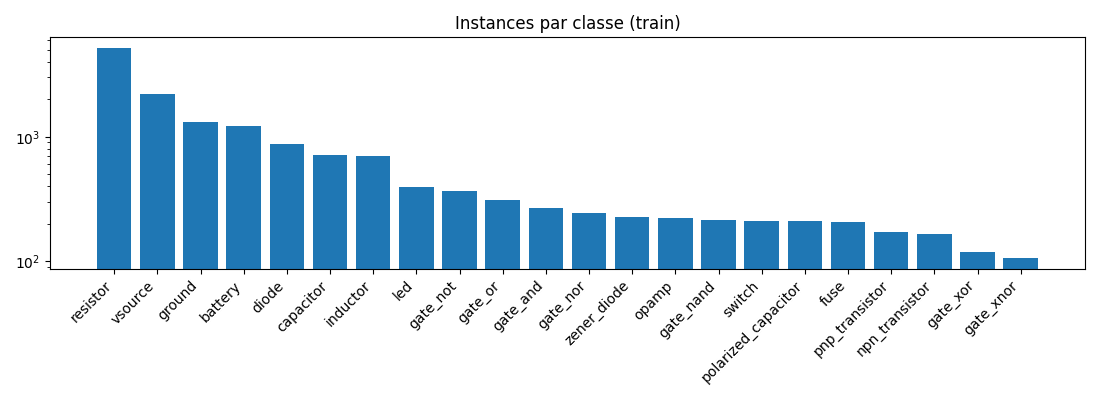

unicité visuelle : 4986/5000 (99.7 %)
logic_and2 [logic]


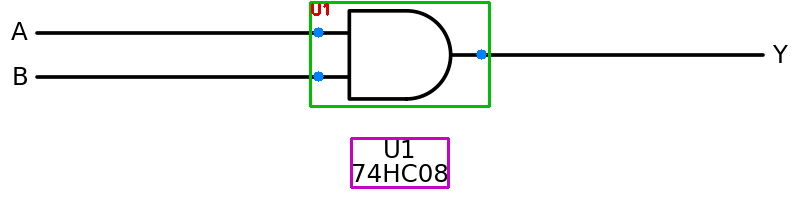

RC_parallel [electrical]


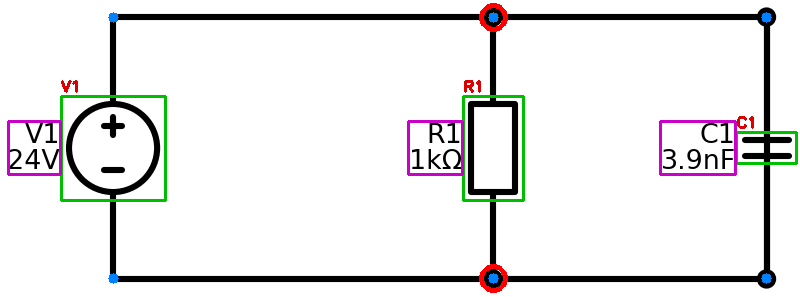

multistage_amplifier [electrical]


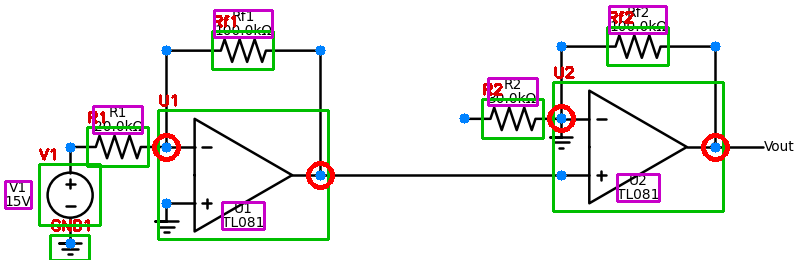

logic_nand_then_nor [logic]


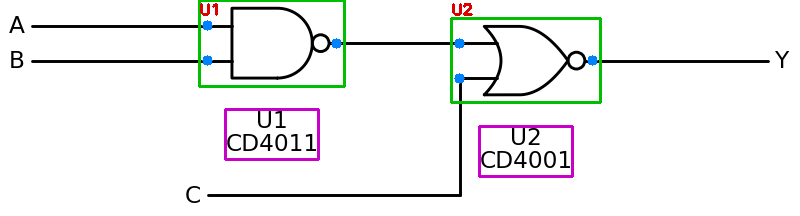

In [14]:
import matplotlib.pyplot as plt

cls_counter = Counter()
for f in (OUT_ROOT/'labels_yolo'/'train').glob('*.txt'):
    for line in f.read_text().splitlines():
        if line.strip():
            cls_counter[CLASS_NAMES[int(line.split()[0])]] += 1

vides = [n for n in CLASS_NAMES if cls_counter.get(n, 0) == 0]
print('classes vides :', vides if vides else 'AUCUNE')
print('instances min :', min(cls_counter.values()),
      '| max :', max(cls_counter.values()))

dom_counter = Counter()
for f in (OUT_ROOT/'annotations'/'train').glob('*.json'):
    dom_counter[json.loads(f.read_text())['domain']] += 1
print('domaines :', dict(dom_counter))

fig, ax = plt.subplots(figsize=(11, 4))
items = cls_counter.most_common()
ax.bar([k for k, _ in items], [v for _, v in items])
ax.set_title('Instances par classe (train)'); ax.set_yscale('log')
plt.xticks(rotation=45, ha='right'); plt.tight_layout()
fig.savefig(TMP/'stats.png', dpi=100); plt.close(fig)
display(IPImage(filename=str(TMP/'stats.png')))

# unicité visuelle (hash perceptuel 32x32)
hashes, n = set(), 0
for f in (OUT_ROOT/'images').rglob('*.png'):
    g = cv2.imread(str(f), cv2.IMREAD_GRAYSCALE)
    hashes.add((cv2.resize(g, (32, 32)) < 128).tobytes()); n += 1
print(f'unicité visuelle : {len(hashes)}/{n} ({100*len(hashes)/n:.1f} %)')

# aperçu annoté
for f in random.sample(sorted((OUT_ROOT/'annotations'/'train').glob('*.json')), 4):
    rec = json.loads(f.read_text(encoding='utf-8'))
    draw_overlay(OUT_ROOT/rec['image'], rec, TMP/'apercu.png')
    print(rec['template'], f"[{rec['domain']}]")
    display(IPImage(filename=str(TMP/'apercu.png'), width=520))